In [51]:
import os
import pandas as pd
import numpy as np
from datetime import datetime

In [52]:
df4 = pd.read_csv("C:\Datathon\dataset\comments4.csv")
df4.shape

(999999, 10)

In [53]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   kind             999999 non-null  object 
 1   commentId        999999 non-null  int64  
 2   channelId        999999 non-null  int64  
 3   videoId          999999 non-null  int64  
 4   authorId         999999 non-null  int64  
 5   textOriginal     999937 non-null  object 
 6   parentCommentId  109338 non-null  float64
 7   likeCount        999999 non-null  int64  
 8   publishedAt      999999 non-null  object 
 9   updatedAt        999999 non-null  object 
dtypes: float64(1), int64(5), object(4)
memory usage: 76.3+ MB


In [54]:
df4.head()

,kind,commentId,channelId,videoId,authorId,textOriginal,parentCommentId,likeCount,publishedAt,updatedAt
0,youtube#comment,1546147,1583,5446,2049014,So nature and amazing ❤,NaN,0,2023-09-06 21:14:57+00:00,2023-09-06 21:14:56+00:00
1,youtube#comment,70185,1658,91495,1676079,"@@xrose2030 so by definition, this commercial ...",913915.0,0,2021-07-02 02:54:27+00:00,2021-07-02 02:54:27+00:00
2,youtube#comment,1315458,22013,48712,164755,Blend blend,NaN,0,2025-01-03 12:16:32+00:00,2025-01-03 12:16:32+00:00
3,youtube#comment,2790969,41246,18969,2963595,East or west India is best,NaN,0,2022-05-31 06:39:58+00:00,2022-05-31 06:39:58+00:00
4,youtube#comment,3834158,41734,27096,2307720,I freaking feel like a student learning new th...,NaN,0,2024-03-31 05:29:58+00:00,2024-03-31 05:29:58+00:00


In [55]:
df4.dtypes

kind                object
commentId            int64
channelId            int64
videoId              int64
authorId             int64
textOriginal        object
parentCommentId    float64
likeCount            int64
publishedAt         object
updatedAt           object
dtype: object

In [64]:
trend = df4[["textOriginal", "likeCount", "publishedAt"]]
trend

,textOriginal,likeCount,publishedAt
0,So nature and amazing ❤,0,2023-09-06 21:14:57+00:00
1,"@@xrose2030 so by definition, this commercial ...",0,2021-07-02 02:54:27+00:00
2,Blend blend,0,2025-01-03 12:16:32+00:00
3,East or west India is best,0,2022-05-31 06:39:58+00:00
4,I freaking feel like a student learning new th...,0,2024-03-31 05:29:58+00:00
...,...,...,...
999994,beneran mirip nyaiii airinnn😭❤️,22,2020-02-06 14:46:35+00:00
999995,THE MAGIC OF MAKEUP,1,2023-06-03 06:25:10+00:00
999996,Wow is so beautiful ❤️❤️❤️❤️🎉🎉,0,2024-08-12 23:54:38+00:00
999997,dead,0,2021-09-25 20:32:49+00:00


In [ ]:
trend.isnull().sum()

textOriginal    62
likeCount        0
publishedAt      0
dtype: int64

In [66]:
trend = trend.dropna(subset=["textOriginal"])
trend

,textOriginal,likeCount,publishedAt
0,So nature and amazing ❤,0,2023-09-06 21:14:57+00:00
1,"@@xrose2030 so by definition, this commercial ...",0,2021-07-02 02:54:27+00:00
2,Blend blend,0,2025-01-03 12:16:32+00:00
3,East or west India is best,0,2022-05-31 06:39:58+00:00
4,I freaking feel like a student learning new th...,0,2024-03-31 05:29:58+00:00
...,...,...,...
999994,beneran mirip nyaiii airinnn😭❤️,22,2020-02-06 14:46:35+00:00
999995,THE MAGIC OF MAKEUP,1,2023-06-03 06:25:10+00:00
999996,Wow is so beautiful ❤️❤️❤️❤️🎉🎉,0,2024-08-12 23:54:38+00:00
999997,dead,0,2021-09-25 20:32:49+00:00


In [67]:
trend.describe()

,likeCount
count,999937.000000
mean,10.397543
std,502.285792
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,194610.000000


In [76]:
trend['publishedAt'] = pd.to_datetime(trend['publishedAt'], format='%Y-%m-%d %H:%M:%S%z', utc=True)
trend.dtypes

C:\Users\User\AppData\Local\Temp\ipykernel_7420\782312746.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trend['publishedAt'] = pd.to_datetime(trend['publishedAt'], format='%Y-%m-%d %H:%M:%S%z', utc=True)


textOriginal                 object
likeCount                     int64
publishedAt     datetime64[ns, UTC]
dtype: object

In [69]:
oldest = trend['publishedAt'].min()
newest = trend['publishedAt'].max()

In [70]:
oldest

Timestamp('2020-01-04 07:53:37+0000', tz='UTC')

In [71]:
newest

Timestamp('2025-07-20 20:15:16+0000', tz='UTC')

In [72]:
import matplotlib.pyplot as plt
%matplotlib inline

In [86]:
def get_half_year(date):
    year = date.year
    half = 'H1' if date.month <= 6 else 'H2'
    return f"{year}-{half}"

trend['half_year'] = trend['publishedAt'].apply(get_half_year)
trend

C:\Users\User\AppData\Local\Temp\ipykernel_7420\1028743470.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trend['half_year'] = trend['publishedAt'].apply(get_half_year)


,textOriginal,likeCount,publishedAt,half_year
0,So nature and amazing ❤,0,2023-09-06 21:14:57+00:00,2023-H2
1,"@@xrose2030 so by definition, this commercial ...",0,2021-07-02 02:54:27+00:00,2021-H2
2,Blend blend,0,2025-01-03 12:16:32+00:00,2025-H1
3,East or west India is best,0,2022-05-31 06:39:58+00:00,2022-H1
4,I freaking feel like a student learning new th...,0,2024-03-31 05:29:58+00:00,2024-H1
...,...,...,...,...
999994,beneran mirip nyaiii airinnn😭❤️,22,2020-02-06 14:46:35+00:00,2020-H1
999995,THE MAGIC OF MAKEUP,1,2023-06-03 06:25:10+00:00,2023-H1
999996,Wow is so beautiful ❤️❤️❤️❤️🎉🎉,0,2024-08-12 23:54:38+00:00,2024-H2
999997,dead,0,2021-09-25 20:32:49+00:00,2021-H2


In [84]:
comment_counts = trend['half_year'].value_counts().sort_index()

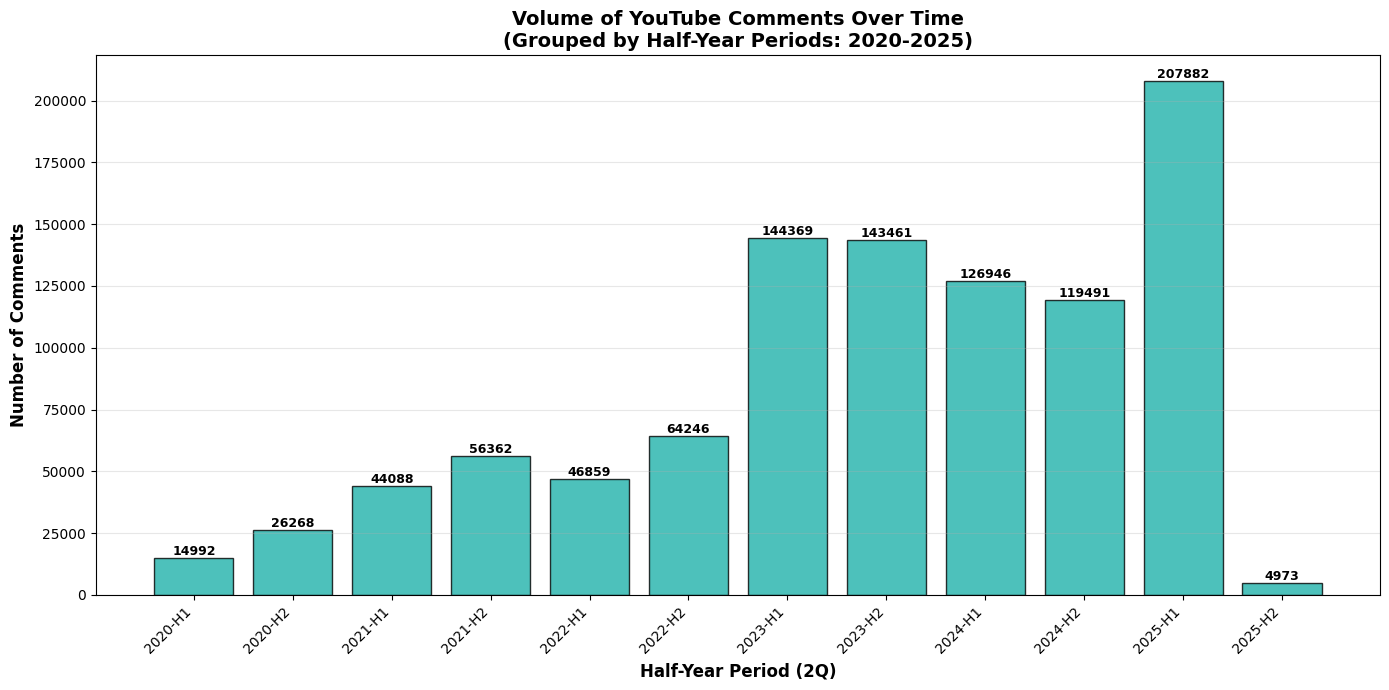

In [85]:
plt.figure(figsize=(14, 7))
bars = plt.bar(comment_counts.index.astype(str), comment_counts.values, 
               color='lightseagreen', edgecolor='black', alpha=0.8)

plt.xlabel('Half-Year Period (2Q)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Comments', fontsize=12, fontweight='bold')
plt.title('Volume of YouTube Comments Over Time\n(Grouped by Half-Year Periods: 2020-2025)', 
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()